# Image Classification Workshop Lab: RGB Variant

This notebook is designed as a first hands-on image-classification lesson for beginners.

This RGB variant keeps the workflow aligned across models by giving both the classical baselines and the CNN color images.

We will:
- load an image dataset from folders,
- choose a classification target,
- inspect class balance and image examples,
- train a simple scikit-learn baseline on RGB inputs,
- train a tiny CNN on the same RGB inputs when PyTorch is available,
- compare accuracy, runtime, and workflow tradeoffs,
- stress-test device predictions on damaged images from the `Defect` folder.

The notebook supports two targets:
- `device_type`: classify `device1`, `device 2`, `device 3`, and future device folders using only the clean device folders for training.
- `damage_status`: classify `Damaged` vs `Not-Damaged` by treating `Defect` as damaged and the normal device folders as not damaged.


## 1. Imports and workshop helpers

This cell loads the tools we need and prepares a runtime log so we can measure how long each major step takes.

In [17]:
# Standard library tools for file paths, timing, and warning control.
from pathlib import Path
import math
import sys
import time
import warnings

# Data-science libraries for plotting, arrays, tables, and image loading.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from IPython.display import Markdown, display
# Classical machine-learning models and helpers used later in the notebook.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# Find the notebook folder so imports and dataset paths work even if the user runs
# the notebook from the repository root instead of inside 0_Class_Notebooks.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "0_Class_Notebooks":
    candidate = NOTEBOOK_DIR / "0_Class_Notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

# Add the notebook folder to Python's import path so our helper file can be imported.
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from workshop_image_utils import (
    available_target_modes,
    create_progress,
    load_image_records,
    load_images_as_arrays,
    record_timing,
    safe_stratify_labels,
    target_column_for_mode,
    timing_frame,
    update_progress,
    validate_target_mode,
)

# Keep charts readable and reduce distracting warning messages for beginners.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# PyTorch is optional in this workshop, so we detect whether it is installed.
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    torch = None
    nn = None
    DataLoader = None
    TensorDataset = None
    print("PyTorch is not installed in this environment, so the CNN section will be skipped.")

# We will store timing measurements here as we move through the notebook.
step_timings = []


## 2. Configuration

Change the values in this cell when you want to switch datasets or tasks.

Beginner note:
- `device_type` trains on clean device folders and can use the `Defect` folder as a separate challenge set.
- `damage_status` asks a binary question: damaged or not damaged.
- Some values in the configuration cell are also hyperparameters, which means they control model behavior rather than just file paths.

Quick guide to the shared settings:
- `IMAGE_SIZE`: resize target for the classical image models. In this RGB notebook, each image contributes three color channels, so larger values create many more input features.
- `TEST_SIZE`: fraction of the dataset held out for testing.
- `RANDOM_STATE`: keeps the split reproducible so students see the same result again.
- `USE_PCA`: turns dimensionality reduction on or off for the scaled flattened-pixel models.
- `PCA_VARIANCE_TO_KEEP`: when PCA is on, keep this share of the original pixel variation.
- `CNN_IMAGE_SIZE`: resize target for the CNN.
- `CNN_EPOCHS`: number of full passes through the training set.
- `CNN_BATCH_SIZE`: how many images the CNN processes before each weight update.
- `CNN_LEARNING_RATE`: how large each CNN optimization step is.

### Student change points

Change one value at a time, rerun from this cell downward, and compare the accuracy, confusion matrix, wrong predictions, and runtime.

- Start with `TARGET_MODE`, `IMAGE_SIZE`, and `TEST_SIZE`.
- Compare this notebook with the grayscale notebook: did RGB color help, hurt, or mostly add extra computation?
- Then try `USE_PCA`, model settings such as `KNeighborsClassifier(n_neighbors=...)`, `DecisionTreeClassifier(max_depth=...)`, or `CNN_EPOCHS`.
- Inspect mistakes before deciding which model is best.


In [18]:
DATASET_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Device_Images").resolve()
METADATA_PATH = DATASET_ROOT / "metadata.csv"  # Optional future file.
TARGET_MODE = "damage_status"  # Student change point: try "device_type" and compare the task difficulty.
INCLUDED_DEVICE_TYPES = ["device1", "device 2"]  # Student change point: add/remove available device folders.
RUN_DEFECT_CHALLENGE = TARGET_MODE == "device_type"
IMAGE_SIZE = 96  # Student change point: RGB has 3 channels, so larger sizes get expensive quickly.
TEST_SIZE = 0.30  # Student change point: try 0.20 or 0.40 and inspect whether scores change.
RANDOM_STATE = 42  # Student change point: change this to see how a different split affects results.
USE_PCA = True  # Student change point: turn on PCA for the scaled flattened-pixel models.
PCA_VARIANCE_TO_KEEP = 0.95  # Student change point: try 0.90, 0.95, or 0.99 when USE_PCA is True.
CNN_IMAGE_SIZE = 64  # Student change point: controls image size for the CNN only.
CNN_EPOCHS = 6  # Student change point: more epochs may improve learning or overfit.
CNN_BATCH_SIZE = 8  # Student change point: changes how many images the CNN sees per update.
CNN_LEARNING_RATE = 0.001  # Student change point: too high or too low can hurt learning.

print(f"Dataset root: {DATASET_ROOT}")
print(f"Metadata file exists: {METADATA_PATH.exists()}")
print(f"Current target mode: {TARGET_MODE}")
print(f"Included device folders: {INCLUDED_DEVICE_TYPES}")
print(f"Run defect challenge after device training: {RUN_DEFECT_CHALLENGE}")
print(f"PCA for scaled flattened-pixel models: {USE_PCA} (variance kept: {PCA_VARIANCE_TO_KEEP:.0%})")


Dataset root: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Metadata file exists: True
Current target mode: damage_status
Included device folders: ['device1', 'device 2']
Run defect challenge after device training: False
PCA for scaled flattened-pixel models: True (variance kept: 95%)


## 3. Load the dataset and inspect available labels

Stop and predict before you run this cell:
- Which task do you think will be easier for a model: device type or damage status?
- What problems could appear if one class has many more images than another?
- Do you think a model trained on clean devices will still recognize damaged ones?


In [19]:
# Load the images into memory and resize them to a shared shape so every model
# starts from the same visual input.
started = time.perf_counter()
all_records = load_image_records(DATASET_ROOT, metadata_path=METADATA_PATH if METADATA_PATH.exists() else None)
load_elapsed = record_timing(step_timings, "dataset_scan", started)

print(f"Loaded {len(all_records)} image records in {load_elapsed:.2f} seconds before workshop filtering.")

standard_device_records = all_records[all_records["is_standard_device_image"]].reset_index(drop=True)
standard_device_records = standard_device_records[standard_device_records["device_type"].isin(INCLUDED_DEVICE_TYPES)].reset_index(drop=True)
defect_challenge_records = all_records[all_records["is_defect_challenge"]].reset_index(drop=True)

print(f"Standard device records after included-device filtering: {len(standard_device_records)}")
print(f"Defect challenge records available: {len(defect_challenge_records)}")

if TARGET_MODE == "device_type":
    records = standard_device_records.copy()
else:
    records = pd.concat([standard_device_records, defect_challenge_records], ignore_index=True)

display(records.head())
print("Available target modes right now:", available_target_modes(records))

is_valid_target, target_message = validate_target_mode(records, TARGET_MODE)
print(target_message)
if not is_valid_target:
    raise ValueError(target_message)

target_column = target_column_for_mode(TARGET_MODE)
records = records[records[target_column].notna()].reset_index(drop=True)
print(f"Records remaining after filtering to labeled rows for {TARGET_MODE}: {len(records)}")

if TARGET_MODE == "device_type" and RUN_DEFECT_CHALLENGE:
    print("Defect images will stay outside the train/test split and be used later as a challenge set.")


Loaded 80 image records in 0.01 seconds before workshop filtering.
Standard device records after included-device filtering: 40
Defect challenge records available: 40


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge
0,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
1,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
2,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_002.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
3,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_010.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
4,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_018.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False


Available target modes right now: ['device_type', 'damage_status']
Target `damage_status` is ready with classes: ['Damaged', 'Not-Damaged']
Records remaining after filtering to labeled rows for damage_status: 80


## 4. Class balance and image inventory

This section helps us answer:
- How many examples do we have for each class?
- Is the dataset balanced?
- Are we at risk of teaching the model from a tiny or biased sample?

For `device_type`, this chart only shows the clean training pool. The damaged `Defect` images are held back for the later stress test.
For `damage_status`, the chart can include both original and augmented clean device images because they all act as `Not-Damaged` examples.


,count
damage_status,
Damaged,40
Not-Damaged,40


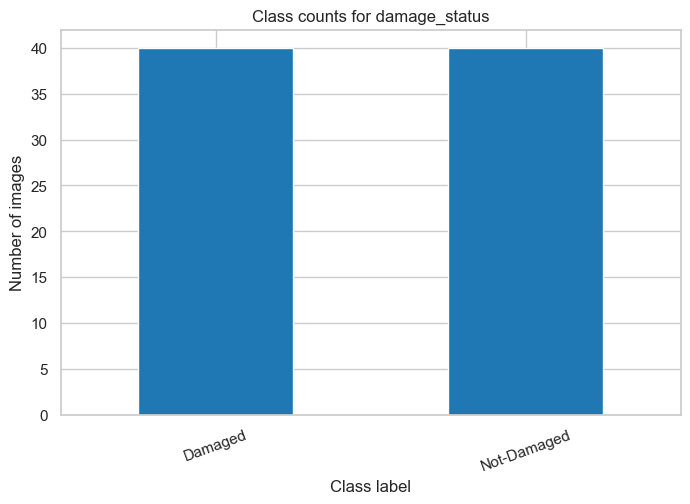

Damage-status note:
Both original and augmented clean device images count as `Not-Damaged` in this binary task.
Defect images and their augmentations count as `Damaged`.
Reflection prompt:
If one class dominates this chart, the model may learn shortcuts instead of the real visual concept.


In [20]:
class_counts = records[target_column].value_counts(dropna=True).sort_index()
display(class_counts.rename("count").to_frame())

ax = class_counts.plot(kind="bar", color="#1f77b4", title=f"Class counts for {TARGET_MODE}")
ax.set_xlabel("Class label")
ax.set_ylabel("Number of images")
plt.xticks(rotation=20)
plt.show()

if TARGET_MODE == "damage_status":
    print("Damage-status note:")
    print("Both original and augmented clean device images count as `Not-Damaged` in this binary task.")
    print("Defect images and their augmentations count as `Damaged`.")

print("Reflection prompt:")
print("If one class dominates this chart, the model may learn shortcuts instead of the real visual concept.")


## 5. Preview example images

Seeing the data matters. Beginners should always inspect a few images before trusting a model.

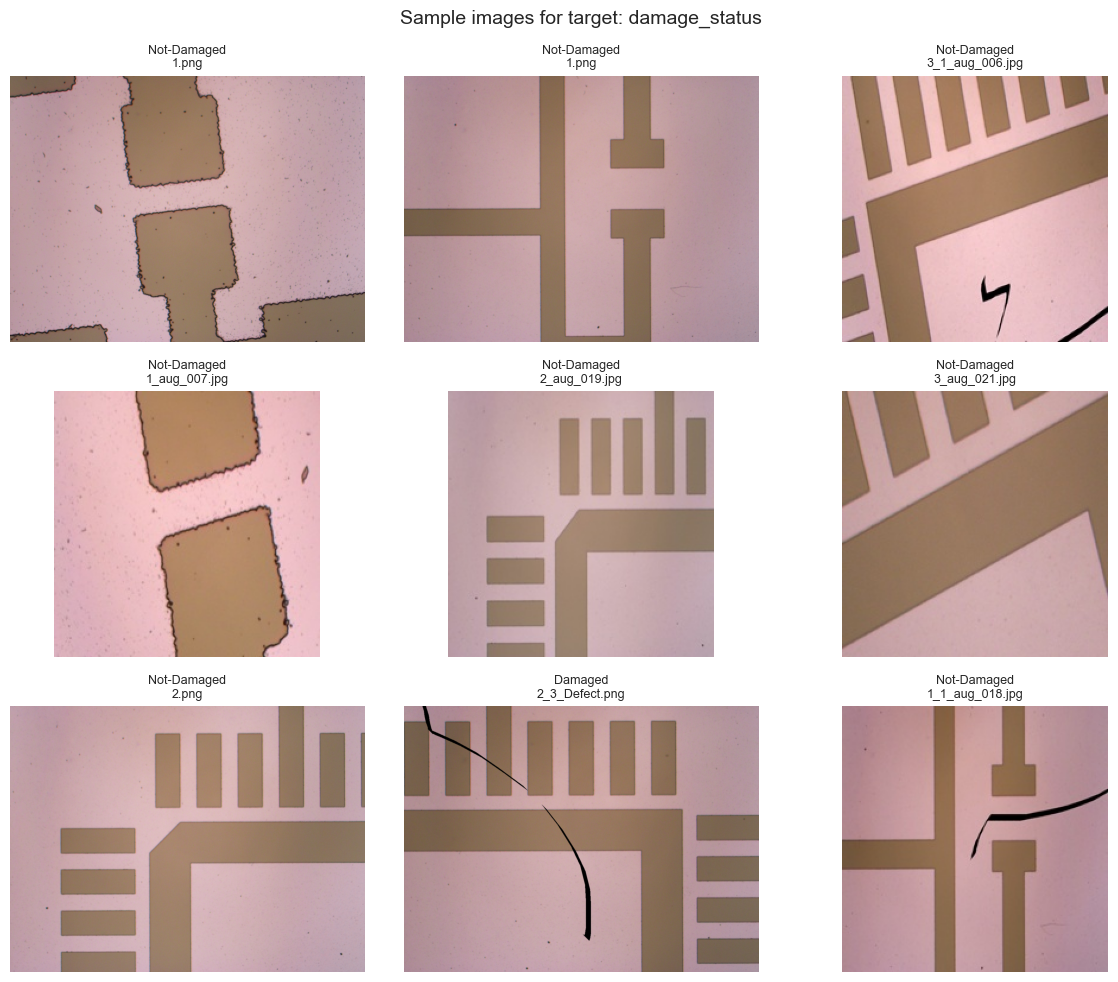

In [21]:
preview_count = min(9, len(records))
sample_records = records.sample(preview_count, random_state=RANDOM_STATE).reset_index(drop=True)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, row in zip(axes, sample_records.itertuples(index=False)):
    with Image.open(row.filepath) as image:
        ax.imshow(image.convert("RGB"))
    label = getattr(row, target_column)
    ax.set_title(f"{label}\n{Path(row.relative_path).name}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Sample images for target: {TARGET_MODE}", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Preprocess images for the classical baseline

We will resize every image to the same shape and convert it into a numerical array.

Why do this?
- Machine-learning models need consistent input shapes.
- A simple baseline helps us understand the workflow before using deep learning.


In [22]:
started = time.perf_counter()
image_arrays, filtered_records = load_images_as_arrays(
    records,
    image_size=IMAGE_SIZE,
    color_mode="rgb",
    progress_title="Preprocess",
)
preprocess_elapsed = record_timing(step_timings, "preprocess_images", started)

# Extract the class label for each image.
labels = filtered_records[target_column].astype(str).to_numpy()
# Flatten each RGB image into one long feature vector and scale pixel values into
# the 0-to-1 range, which makes classical models easier to train.
X = image_arrays.reshape(len(image_arrays), -1) / 255.0

# These placeholders are used only for the later defect challenge section.
defect_challenge_X = None
defect_challenge_gray_records = None
if TARGET_MODE == "device_type" and RUN_DEFECT_CHALLENGE and not defect_challenge_records.empty:
    defect_arrays, defect_challenge_gray_records = load_images_as_arrays(
        defect_challenge_records,
        image_size=IMAGE_SIZE,
        color_mode="rgb",
        progress_title="Defect challenge",
    )
    defect_challenge_X = defect_arrays.reshape(len(defect_arrays), -1) / 255.0

print(f"Processed {len(filtered_records)} images in {preprocess_elapsed:.2f} seconds.")
print("Feature matrix shape:", X.shape)
print("Image tensor shape before flattening:", image_arrays.shape)
print(f"Active dataset root used for training: {DATASET_ROOT}")
if TARGET_MODE == "damage_status":
    training_damage_counts = filtered_records["damage_status"].value_counts(dropna=True).sort_index()
    print("Final damage-status counts used for training:")
    display(training_damage_counts.rename("count").to_frame())
if defect_challenge_X is not None:
    print(f"Prepared {len(defect_challenge_gray_records)} damaged challenge images for later device-type inference.")


Processed 80 images in 0.92 seconds.
Feature matrix shape: (80, 27648)
Image tensor shape before flattening: (80, 96, 96, 3)
Active dataset root used for training: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Final damage-status counts used for training:


,count
damage_status,
Damaged,40
Not-Damaged,40


## 7. Train/test split

Stop and predict before running:
- If the dataset is tiny, do you expect the score to be stable every time?
- Why might a different random split change the final accuracy?

In [23]:
# Stratification tries to preserve the class balance in both the train and test sets.
stratify_labels = safe_stratify_labels(labels)
X_train, X_test, y_train, y_test, train_records, test_records = train_test_split(
    X,
    labels,
    filtered_records,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

print("Train set size:", len(X_train))
print("Test set size:", len(X_test))
print("Used stratified split:", stratify_labels is not None)

Train set size: 56
Test set size: 24
Used stratified split: True


## 8. Shared evaluation helpers

These helper functions keep the evaluation format consistent across all models so students can compare them fairly.


In [24]:
model_summaries = []


def make_scaled_pixel_estimator(classifier):
    steps = [("scale", StandardScaler())]
    if USE_PCA:
        steps.append(("pca", PCA(n_components=PCA_VARIANCE_TO_KEEP, random_state=RANDOM_STATE)))
    steps.append(("clf", classifier))
    return Pipeline(steps)


def _render_gallery_image(image_data, color_mode="grayscale", image_size=None):
    if color_mode == "grayscale":
        if image_size is None:
            raise ValueError("image_size is required for grayscale galleries.")
        return image_data.reshape(image_size, image_size), {"cmap": "gray"}
    if image_data.ndim == 1:
        if image_size is None:
            raise ValueError("image_size is required for flattened RGB galleries.")
        return image_data.reshape(image_size, image_size, 3), {}
    return image_data, {}


def _softmax_rows(values):
    values = np.asarray(values, dtype=float)
    shifted = values - values.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


def estimate_prediction_confidence(estimator, X_values):
    if hasattr(estimator, "predict_proba"):
        probabilities = estimator.predict_proba(X_values)
        return probabilities.max(axis=1), "Confidence"

    if hasattr(estimator, "decision_function"):
        decision = estimator.decision_function(X_values)
        if np.ndim(decision) == 1:
            confidence = 1.0 / (1.0 + np.exp(-np.abs(decision)))
        else:
            confidence = _softmax_rows(decision).max(axis=1)
        return confidence, "Confidence"

    return None, None


def show_prediction_gallery(images, truths, preds, indices, title, color_mode="grayscale", image_size=None, max_images=6, confidences=None, confidence_label="Confidence"):
    selected = list(indices)[:max_images]
    if not selected:
        display(Markdown(f"**{title}:** none available in this split."))
        return

    columns = min(3, len(selected))
    rows = math.ceil(len(selected) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, selected):
        rendered, kwargs = _render_gallery_image(images[idx], color_mode=color_mode, image_size=image_size)
        ax.imshow(rendered, **kwargs)
        title_lines = [f"True: {truths[idx]}", f"Pred: {preds[idx]}"]
        if confidences is not None:
            title_lines.append(f"{confidence_label}: {float(confidences[idx]):.2f}")
        ax.set_title("\n".join(title_lines), fontsize=10)
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def evaluate_predictions(model_name, truths, preds, images, color_mode="grayscale", image_size=None, cmap="Blues", confidences=None, confidence_label="Confidence"):
    labels_sorted = sorted(pd.unique(np.array(truths, dtype=object)))
    cm = confusion_matrix(truths, preds, labels=labels_sorted)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.title(f"{model_name} confusion matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

    correct_indices = [idx for idx, (truth, pred) in enumerate(zip(truths, preds)) if truth == pred]
    incorrect_indices = [idx for idx, (truth, pred) in enumerate(zip(truths, preds)) if truth != pred]

    show_prediction_gallery(
        images,
        truths,
        preds,
        correct_indices,
        title=f"{model_name}: correctly predicted images",
        color_mode=color_mode,
        image_size=image_size,
        confidences=confidences,
        confidence_label=confidence_label,
    )
    show_prediction_gallery(
        images,
        truths,
        preds,
        incorrect_indices,
        title=f"{model_name}: incorrectly predicted images",
        color_mode=color_mode,
        image_size=image_size,
        confidences=confidences,
        confidence_label=confidence_label,
    )


def fit_and_evaluate_classical_model(model_name, estimator, X_train, y_train, X_test, y_test, image_arrays, image_size, timing_key, cmap="Blues", prediction_decoder=None):
    # Train the model on the training split.
    started = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_elapsed = record_timing(step_timings, f"{timing_key}_train", started)

    estimator_uses_pca = hasattr(estimator, "named_steps") and "pca" in estimator.named_steps
    if estimator_uses_pca:
        pca_step = estimator.named_steps["pca"]
        print(f"{model_name} PCA components kept: {pca_step.n_components_} of {X_train.shape[1]} original features")

    # Ask the trained model to predict labels for the held-out test split.
    started = time.perf_counter()
    predictions = estimator.predict(X_test)
    predict_elapsed = record_timing(step_timings, f"{timing_key}_predict", started)

    # Compute a simple summary score plus optional confidence values when the model
    # exposes them.
    confidences, confidence_label = estimate_prediction_confidence(estimator, X_test)
    accuracy = accuracy_score(y_test, predictions)
    display_truths = prediction_decoder(np.asarray(y_test)) if prediction_decoder is not None else np.asarray(y_test)
    display_predictions = prediction_decoder(np.asarray(predictions)) if prediction_decoder is not None else np.asarray(predictions)
    print(f"{model_name} training time: {train_elapsed:.2f} seconds")
    print(f"{model_name} prediction time: {predict_elapsed:.4f} seconds")
    print(f"{model_name} accuracy: {accuracy:.3f}")
    if confidences is not None:
        print(f"Average {confidence_label.lower()}: {float(np.mean(confidences)):.3f}")
    print(classification_report(display_truths, display_predictions))

    # Reuse the same plots and error inspection tools for every classical model.
    evaluate_predictions(
        model_name,
        truths=list(display_truths),
        preds=list(display_predictions),
        images=image_arrays,
        color_mode="rgb",
        image_size=image_size,
        cmap=cmap,
        confidences=confidences,
        confidence_label=confidence_label or "Confidence",
    )

    # Save the detailed results so we can compare models later in one place.
    result = {
        "model": model_name,
        "accuracy": float(accuracy),
        "train_seconds": float(train_elapsed),
        "predict_seconds": float(predict_elapsed),
        "estimator": estimator,
        "predictions": display_predictions,
        "raw_predictions": predictions,
        "confidences": confidences,
        "confidence_label": confidence_label,
    }
    model_summaries.append({
        "model": model_name,
        "accuracy": round(float(accuracy), 3),
        "train_seconds": round(float(train_elapsed), 3),
        "predict_seconds": round(float(predict_elapsed), 4),
        "pca": "on" if estimator_uses_pca else "off",
    })
    return result


## 9. Logistic regression

This stays as the main linear classification baseline for the workshop.

Hyperparameter notes:
- `max_iter=2000`: gives the optimizer more chances to converge. If this is too small, training can stop before the model settles.
- `StandardScaler()`: not a hyperparameter itself, but it helps by putting pixel features on a comparable scale before logistic regression learns.


Logistic Regression PCA components kept: 37 of 27648 original features
Logistic Regression training time: 0.20 seconds
Logistic Regression prediction time: 0.0114 seconds
Logistic Regression accuracy: 0.583
Average confidence: 0.966
              precision    recall  f1-score   support

     Damaged       0.58      0.58      0.58        12
 Not-Damaged       0.58      0.58      0.58        12

    accuracy                           0.58        24
   macro avg       0.58      0.58      0.58        24
weighted avg       0.58      0.58      0.58        24



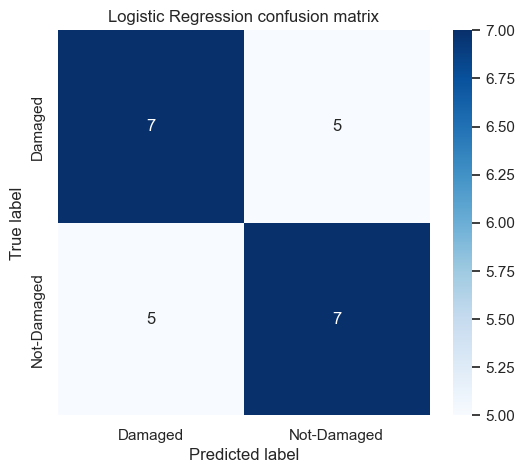

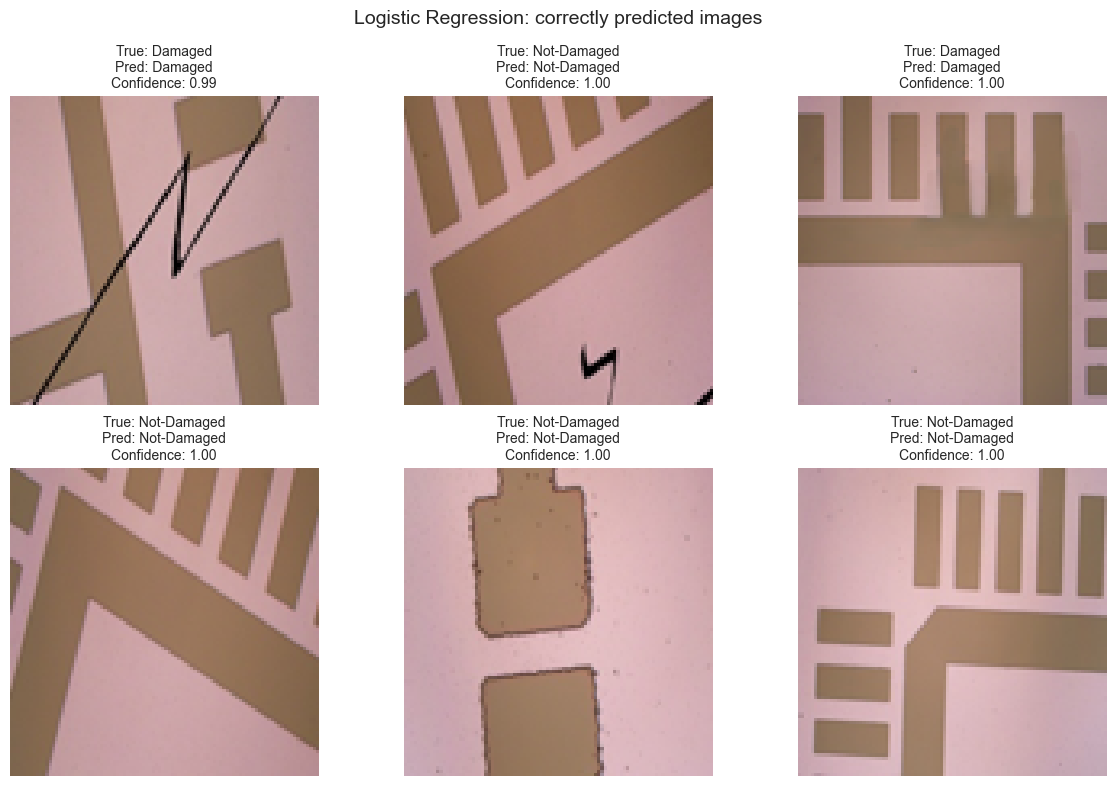

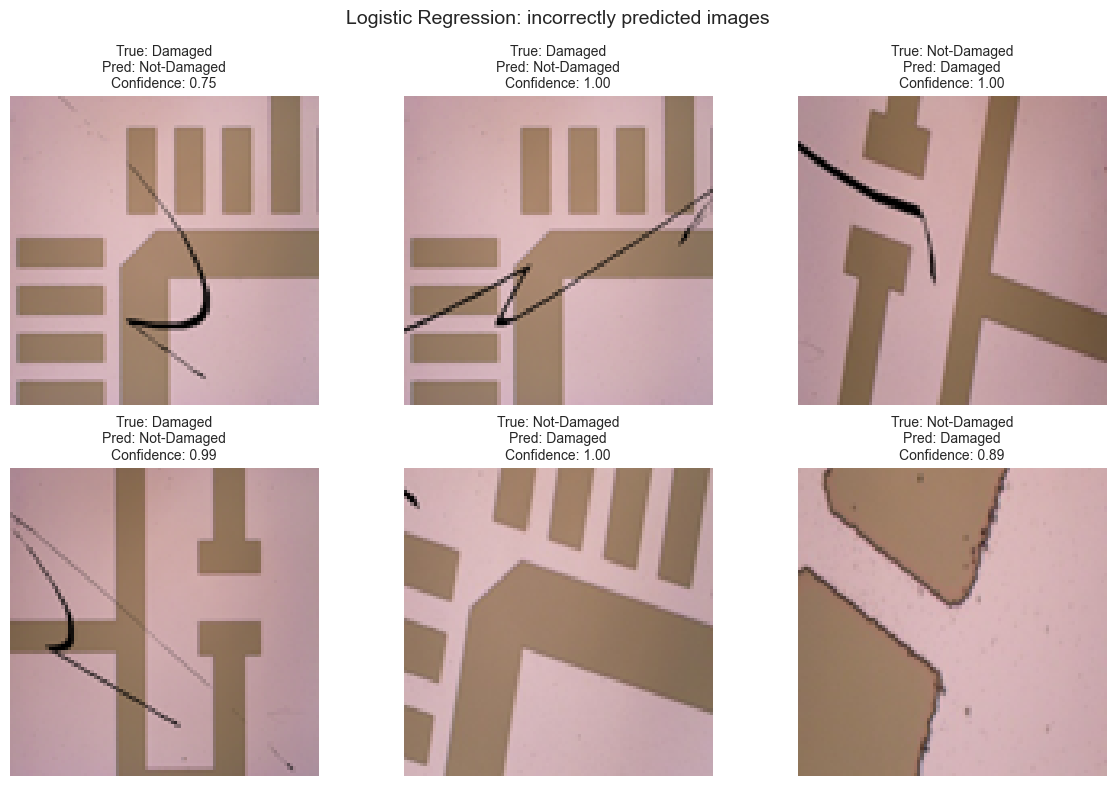

In [25]:
logistic_model = make_scaled_pixel_estimator(
    LogisticRegression(max_iter=2000),
)
logistic_results = fit_and_evaluate_classical_model(
    model_name="Logistic Regression",
    estimator=logistic_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="logistic",
    cmap="Blues",
)


## 10. Decision tree

Decision trees are easier to explain visually, but they can also overfit tiny datasets quickly.

Hyperparameter notes:
- `random_state=RANDOM_STATE`: makes the learned tree reproducible.
- This notebook is using the default tree depth, so the tree can keep growing until the stopping rules are met. That can make it flexible, but also easier to overfit.


Decision Tree training time: 0.44 seconds
Decision Tree prediction time: 0.0013 seconds
Decision Tree accuracy: 0.500
Average confidence: 1.000
              precision    recall  f1-score   support

     Damaged       0.50      0.33      0.40        12
 Not-Damaged       0.50      0.67      0.57        12

    accuracy                           0.50        24
   macro avg       0.50      0.50      0.49        24
weighted avg       0.50      0.50      0.49        24



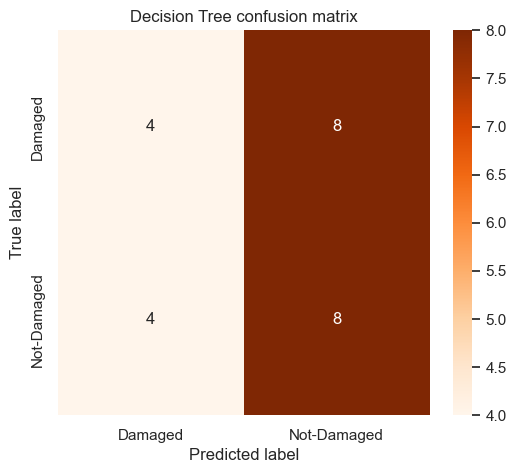

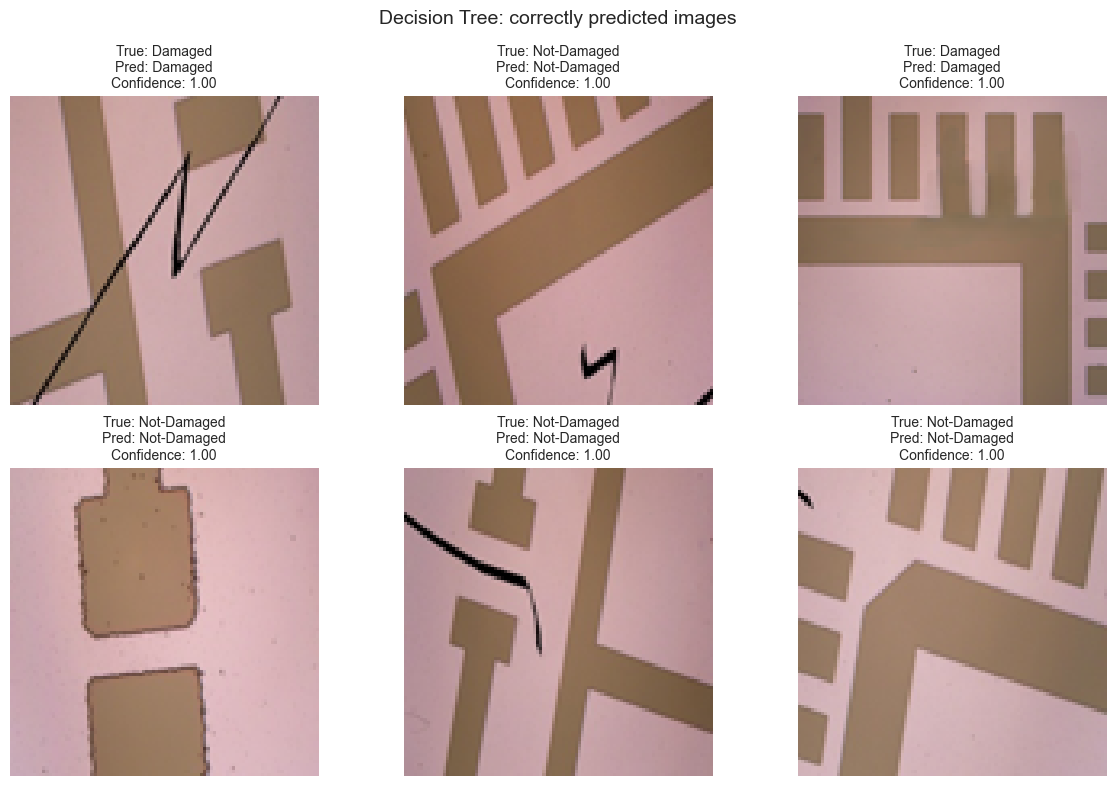

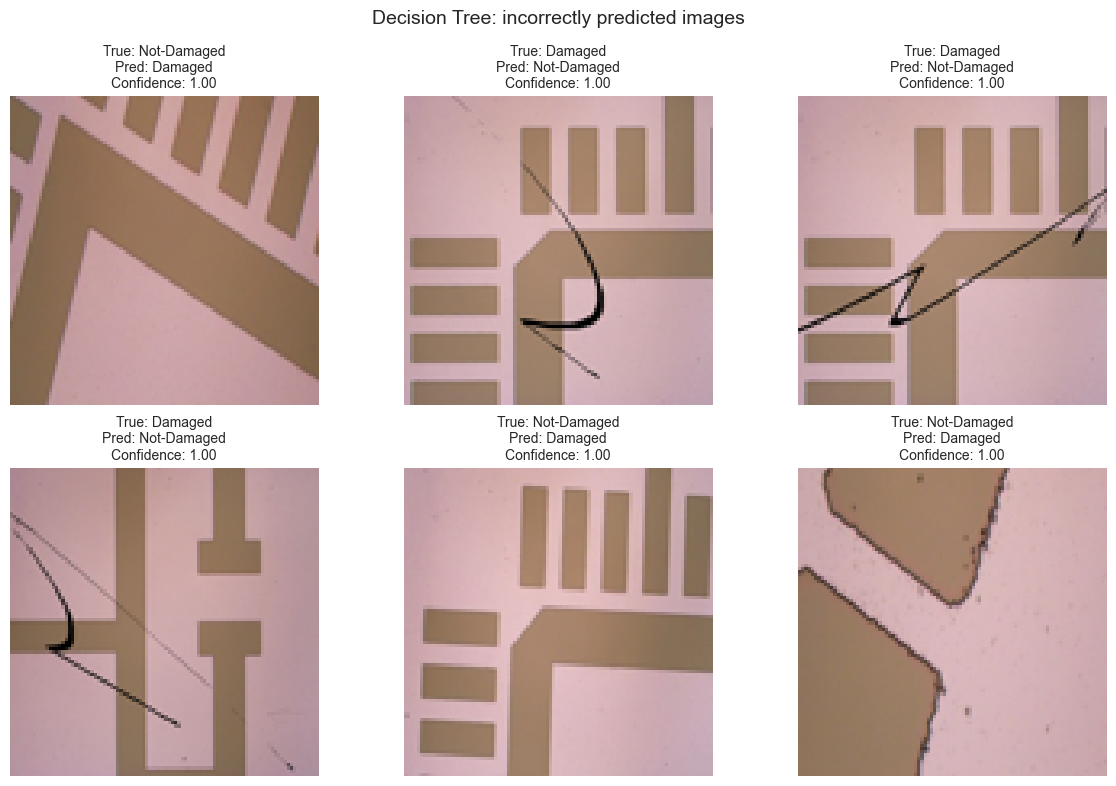

In [26]:
decision_tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_results = fit_and_evaluate_classical_model(
    model_name="Decision Tree",
    estimator=decision_tree_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="decision_tree",
    cmap="Oranges",
)


## 11. K-nearest neighbors

K-nearest neighbors compares each test image to the training set instead of learning a single decision boundary.

Hyperparameter notes:
- `n_neighbors=3`: each prediction is based on the 3 closest training examples. Smaller values react more to local detail; larger values make the boundary smoother.
- `StandardScaler()`: helps distance-based methods like KNN because feature scale affects which points count as nearest neighbors.


K-Nearest Neighbors PCA components kept: 37 of 27648 original features
K-Nearest Neighbors training time: 0.13 seconds
K-Nearest Neighbors prediction time: 0.0108 seconds
K-Nearest Neighbors accuracy: 0.458
Average confidence: 0.722
              precision    recall  f1-score   support

     Damaged       0.47      0.58      0.52        12
 Not-Damaged       0.44      0.33      0.38        12

    accuracy                           0.46        24
   macro avg       0.46      0.46      0.45        24
weighted avg       0.46      0.46      0.45        24



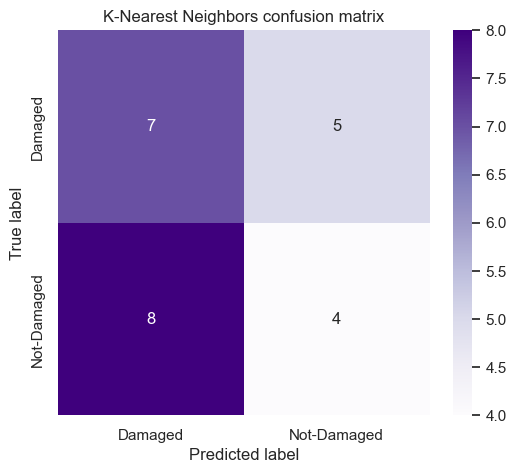

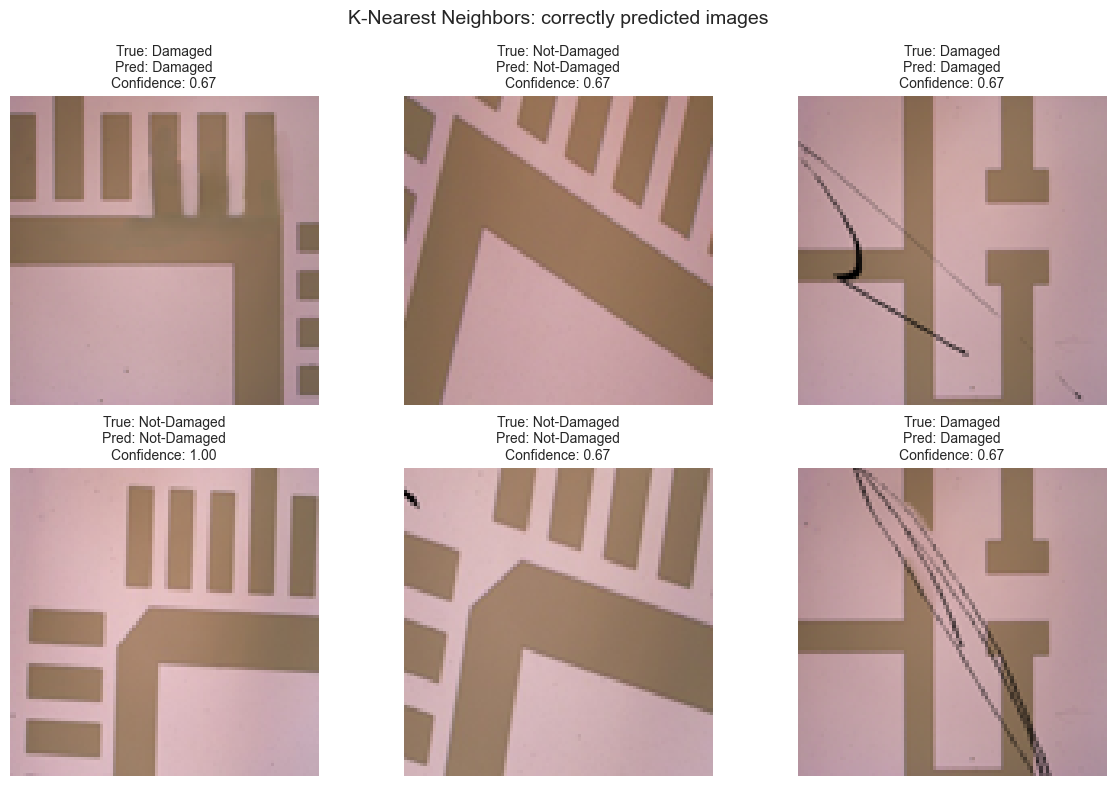

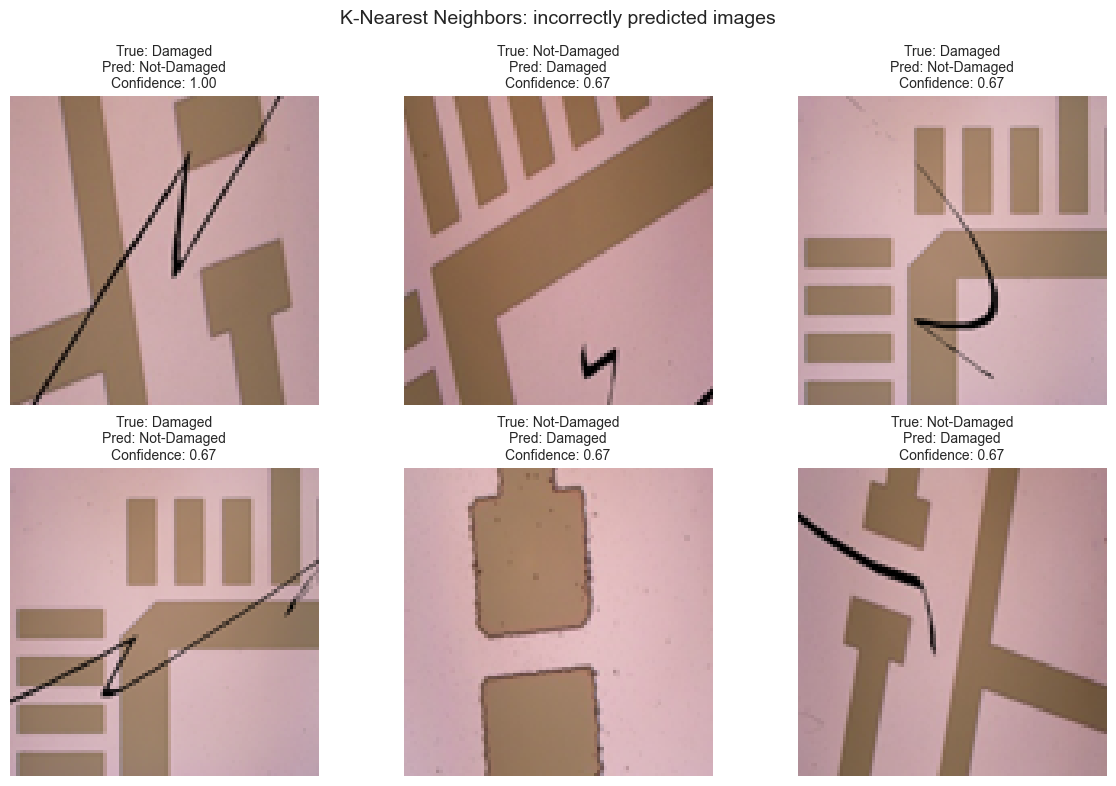

In [27]:
knn_model = make_scaled_pixel_estimator(
    KNeighborsClassifier(n_neighbors=3),
)
knn_results = fit_and_evaluate_classical_model(
    model_name="K-Nearest Neighbors",
    estimator=knn_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="knn",
    cmap="Purples",
)


## 12. Linear SVC

Linear SVC is another linear classifier. It predicts labels directly, but it does not provide class probabilities by default.

Hyperparameter notes:
- `max_iter=5000`: allows more optimization steps before the solver stops.
- `random_state=RANDOM_STATE`: keeps the run reproducible.
- `StandardScaler()`: helps linear margin-based models train more stably on pixel features.


Linear SVC PCA components kept: 37 of 27648 original features
Linear SVC training time: 0.16 seconds
Linear SVC prediction time: 0.0053 seconds
Linear SVC accuracy: 0.667
Average confidence: 0.939
              precision    recall  f1-score   support

     Damaged       0.70      0.58      0.64        12
 Not-Damaged       0.64      0.75      0.69        12

    accuracy                           0.67        24
   macro avg       0.67      0.67      0.66        24
weighted avg       0.67      0.67      0.66        24



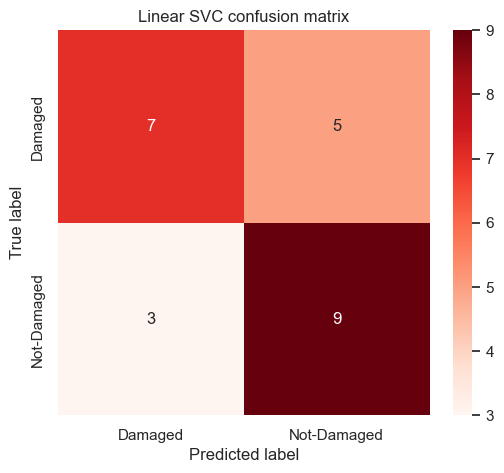

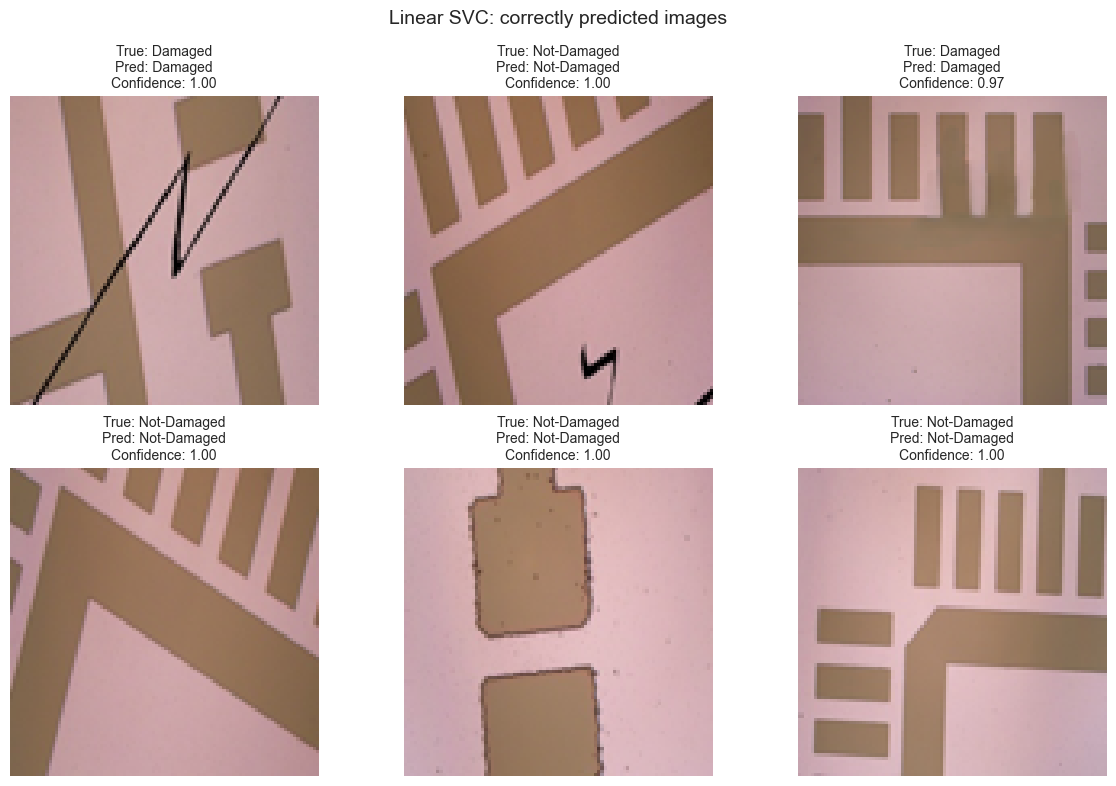

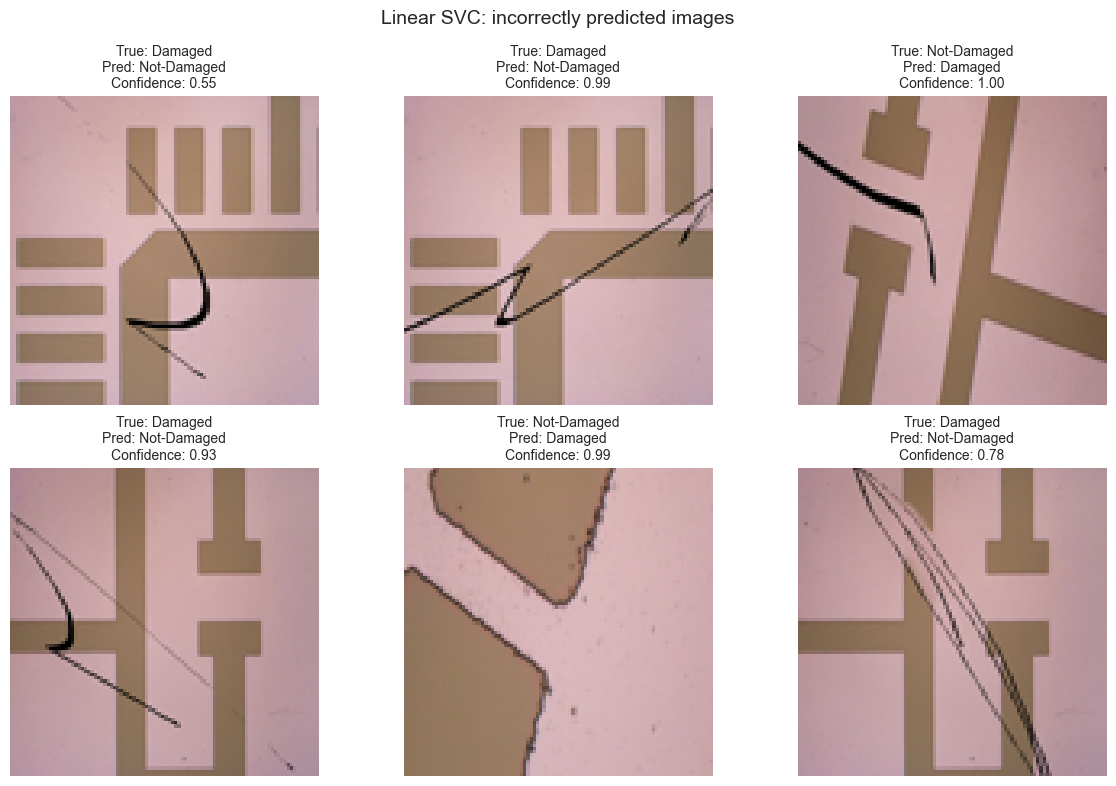

In [28]:
linear_svc_model = make_scaled_pixel_estimator(
    LinearSVC(max_iter=5000, random_state=RANDOM_STATE),
)
linear_svc_results = fit_and_evaluate_classical_model(
    model_name="Linear SVC",
    estimator=linear_svc_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="linear_svc",
    cmap="Reds",
)


## 13. Multi-layer perceptron (MLP)

An MLP is still working on flattened RGB pixels like the other classical models, but it can learn non-linear relationships through hidden layers.

Teaching note: this gives us a neural-network baseline before the CNN section. The key difference is that the MLP still sees the image as one long feature vector, while the CNN keeps the 2D image layout and color channels.

Hyperparameter notes:
- `hidden_layer_sizes=(128,)`: uses one hidden layer with 128 neurons, which keeps the model expressive without becoming too large for this small dataset.
- `early_stopping=True`: automatically holds out part of the training data and stops when validation performance stops improving.
- `max_iter=500`: gives the optimizer enough passes to learn if early stopping does not trigger first.
- `StandardScaler()`: helps gradient-based neural networks train more reliably because the pixel features are on a comparable scale.


MLP PCA components kept: 37 of 27648 original features
MLP training time: 0.13 seconds
MLP prediction time: 0.0052 seconds
MLP accuracy: 0.625
Average confidence: 0.951
              precision    recall  f1-score   support

     Damaged       0.64      0.58      0.61        12
 Not-Damaged       0.62      0.67      0.64        12

    accuracy                           0.62        24
   macro avg       0.63      0.62      0.62        24
weighted avg       0.63      0.62      0.62        24



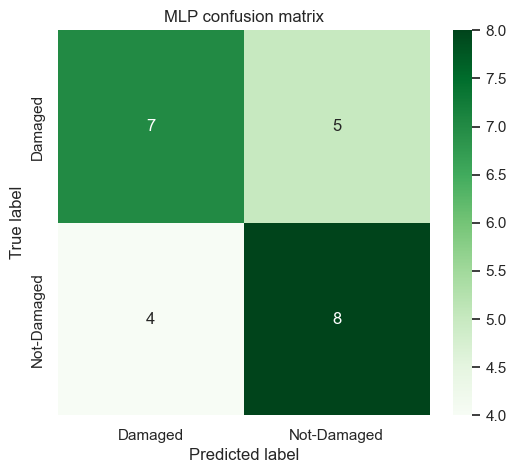

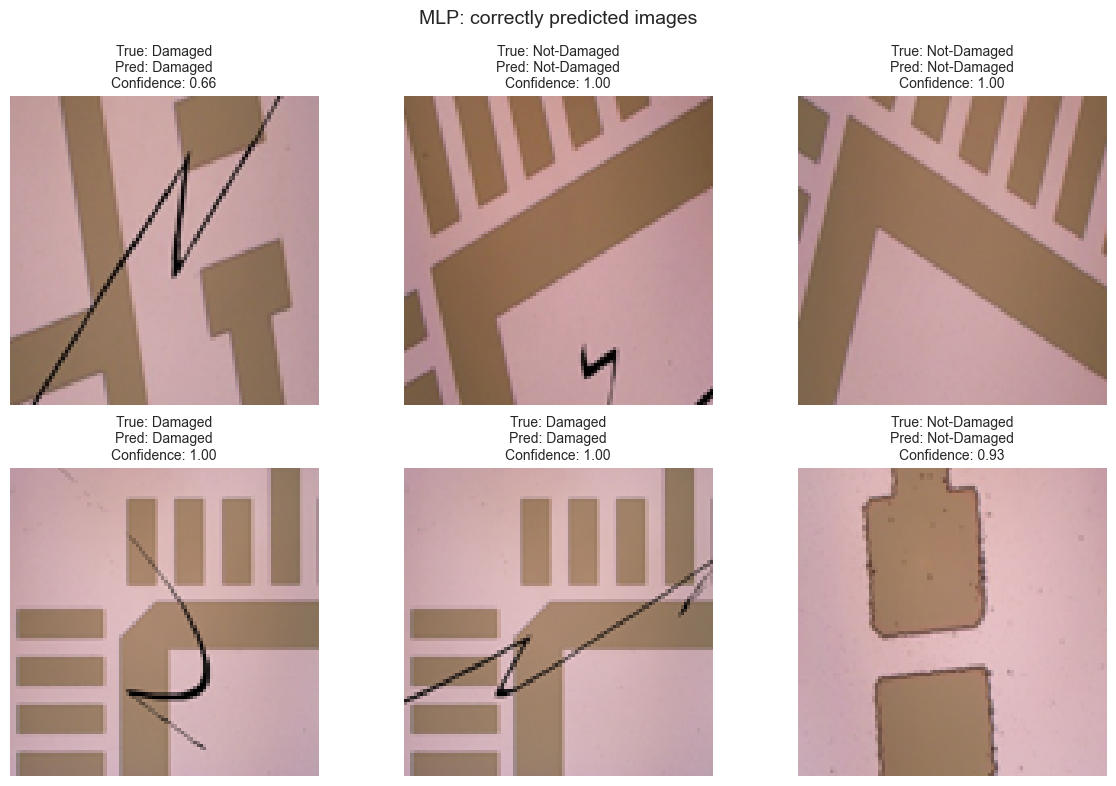

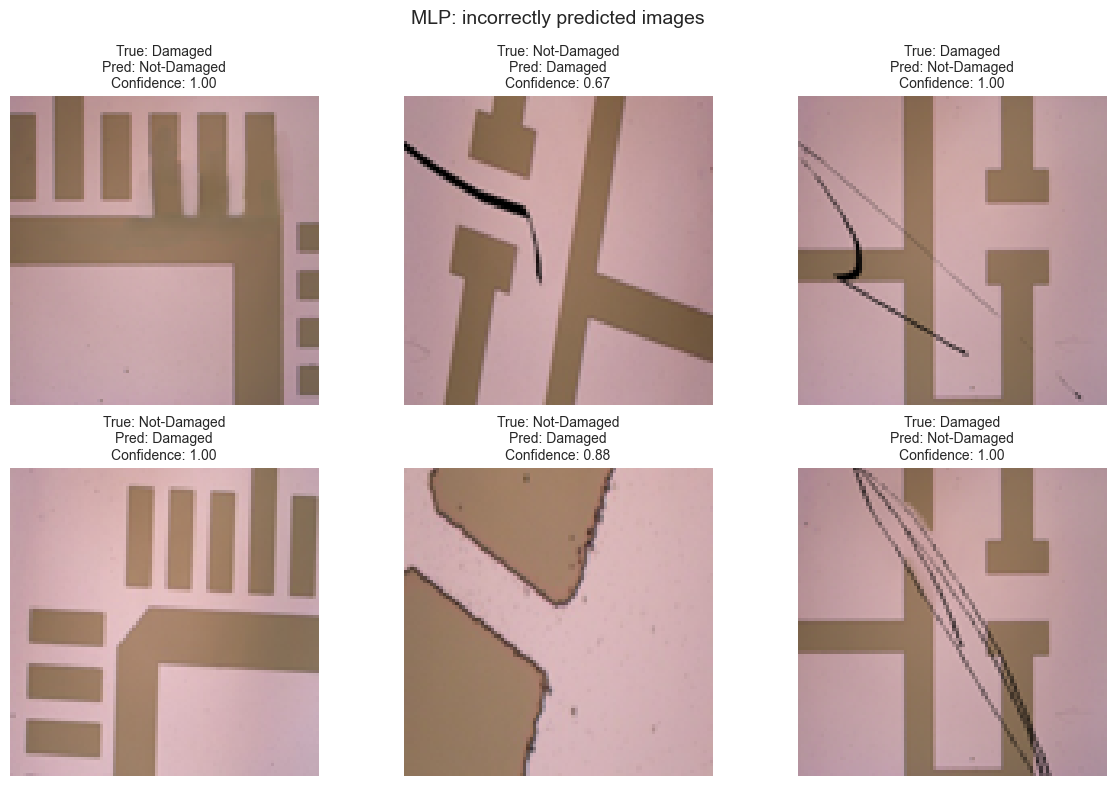

In [29]:
# Encode the class labels as integers so sklearn's internal early-stopping
# validation loop can score the MLP reliably on this environment.
mlp_label_encoder = LabelEncoder()
y_train_mlp = mlp_label_encoder.fit_transform(np.asarray(y_train))
y_test_mlp = mlp_label_encoder.transform(np.asarray(y_test))

# The MLP is a neural network, but it still works on flattened pixels.
mlp_model = make_scaled_pixel_estimator(
    MLPClassifier(hidden_layer_sizes=(128,), early_stopping=True, max_iter=500, random_state=RANDOM_STATE),
)
mlp_results = fit_and_evaluate_classical_model(
    model_name="MLP",
    estimator=mlp_model,
    X_train=X_train,
    y_train=y_train_mlp,
    X_test=X_test,
    y_test=y_test_mlp,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="mlp",
    cmap="Greens",
    prediction_decoder=mlp_label_encoder.inverse_transform,
)


## 14. Tiny CNN

Convolutional neural networks can learn spatial image patterns better than flattened classical baselines.

Fair-comparison note: in this notebook, every model uses RGB images so the comparison focuses on model behavior rather than whether color information was available.

CNN hyperparameter notes:
- `CNN_IMAGE_SIZE=64`: every image is resized to `64 x 64` before entering the CNN.
- `CNN_EPOCHS=6`: the model sees the full training set 6 times. More epochs can improve learning, but too many can overfit.
- `CNN_BATCH_SIZE=8`: the optimizer updates after every 8 training images. Smaller batches are noisier; larger batches are steadier but use more memory.
- `CNN_LEARNING_RATE=0.001`: controls how large each Adam update is. Too high can make training unstable; too low can make learning very slow.

CNN architecture notes:
- `Conv2d(..., 16, kernel_size=3, padding=1)`: first convolution layer learns 16 feature maps from `3x3` image patches while preserving image size.
- `MaxPool2d(2)`: halves the spatial width and height, which reduces computation and keeps stronger signals.
- `Conv2d(16, 32, ...)`: second convolution layer learns 32 higher-level feature maps.
- `Linear(..., 64)`: dense hidden layer with 64 units after the convolution blocks.
- `Dropout(0.2)`: randomly turns off 20% of hidden units during training to reduce overfitting.
- `Linear(64, num_classes)`: final output layer, one score per class.


CNN preprocessing time: 0.90 seconds
CNN training time: 0.32 seconds
CNN prediction time: 0.0077 seconds
CNN accuracy: 0.500
              precision    recall  f1-score   support

     Damaged       0.50      1.00      0.67        12
 Not-Damaged       0.00      0.00      0.00        12

    accuracy                           0.50        24
   macro avg       0.25      0.50      0.33        24
weighted avg       0.25      0.50      0.33        24



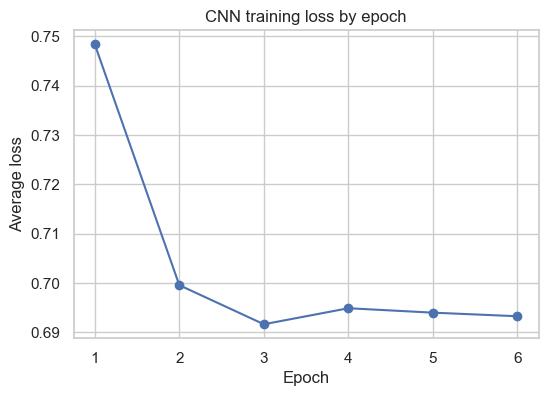

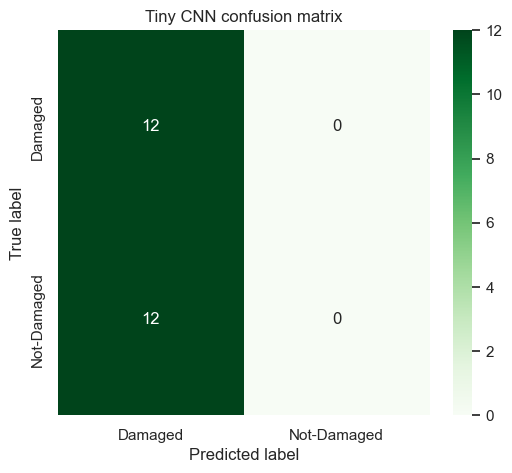

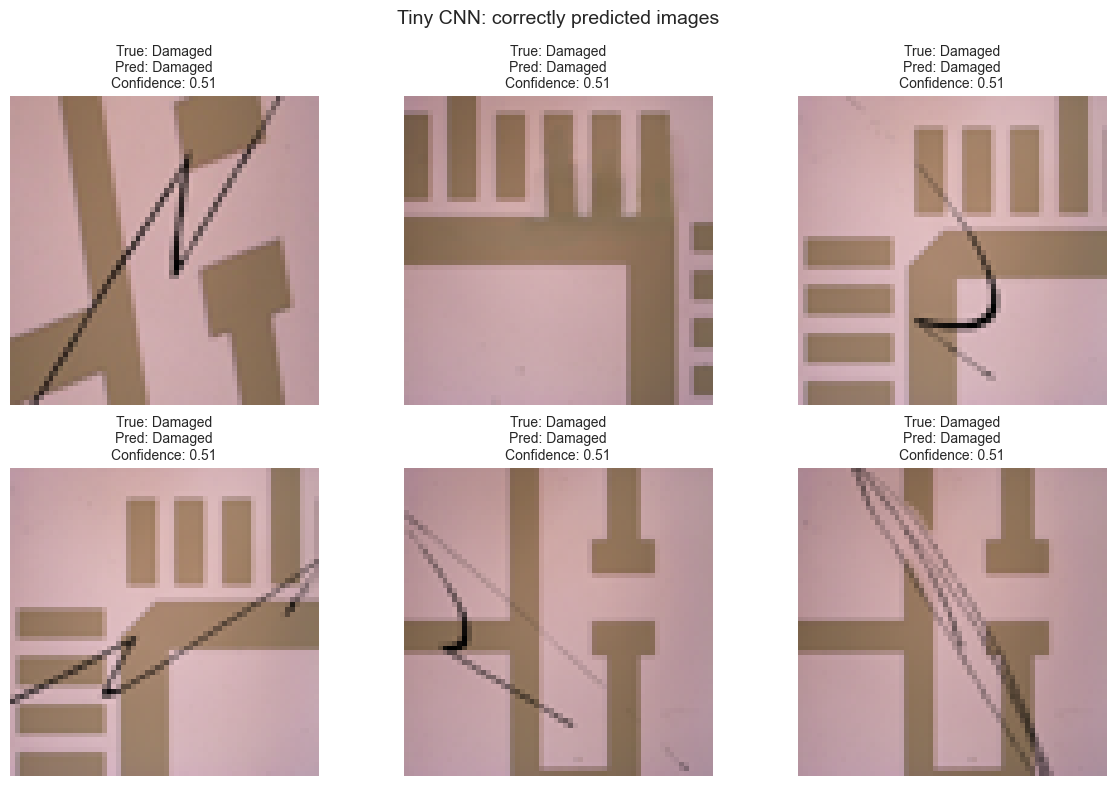

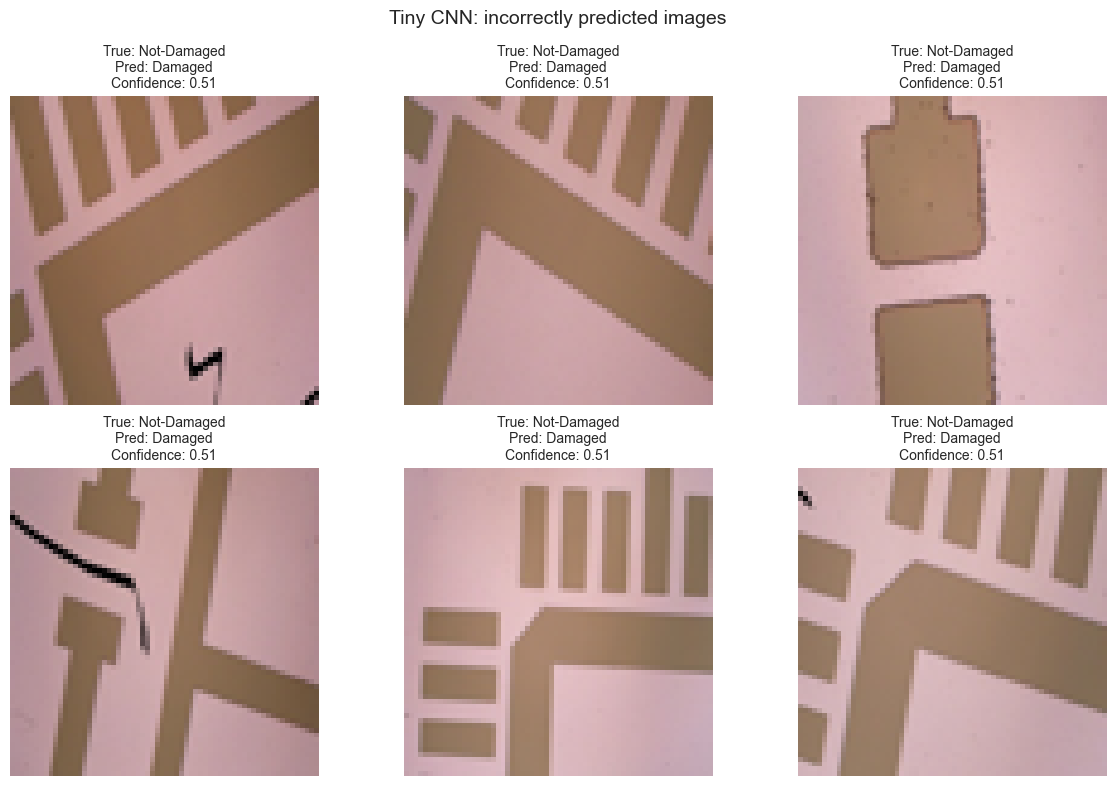

In [30]:
cnn_results = None
cnn_model = None
cnn_label_names = None
cnn_defect_challenge_records = None
# These variables let us optionally test the CNN on damaged images that were never
# part of the normal training or test split.
cnn_defect_challenge_arrays = None

def _prepare_cnn_challenge_arrays(records):
    # Prepare challenge images in the same format used by the CNN training pipeline.
    arrays, filtered = load_images_as_arrays(
        records,
        image_size=CNN_IMAGE_SIZE,
        color_mode="rgb",
        progress_title="CNN defect challenge",
    )
    return arrays, filtered

if not TORCH_AVAILABLE:
    display(Markdown("**CNN skipped:** install PyTorch from `requirements.txt` to run this section."))
else:
    # Load the RGB images for the CNN. Unlike the classical models, the CNN keeps
    # the 2D image layout and color channels instead of flattening immediately.
    started = time.perf_counter()
    cnn_arrays, cnn_records = load_images_as_arrays(
        filtered_records,
        image_size=CNN_IMAGE_SIZE,
        color_mode="rgb",
        progress_title="CNN images",
    )
    cnn_prep_elapsed = record_timing(step_timings, "cnn_preprocess", started)

    # Convert human-readable class names into integer IDs because neural networks
    # train on numbers, not strings.
    cnn_labels = cnn_records[target_column].astype(str).to_numpy()
    cnn_label_names = sorted(pd.unique(cnn_labels))
    label_to_index = {label: idx for idx, label in enumerate(cnn_label_names)}
    y_encoded = np.array([label_to_index[label] for label in cnn_labels])

    stratify_cnn = safe_stratify_labels(y_encoded)
    X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
        cnn_arrays,
        y_encoded,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_cnn,
    )

    # Rearrange the arrays from [batch, height, width, channels] into the PyTorch
    # format [batch, channels, height, width].
    X_train_tensor = torch.tensor(X_train_cnn.transpose(0, 3, 1, 2) / 255.0, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_cnn.transpose(0, 3, 1, 2) / 255.0, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_cnn, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test_cnn, dtype=torch.long)

    # DataLoaders feed the network mini-batches instead of the entire dataset at once.
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=CNN_BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=CNN_BATCH_SIZE, shuffle=False)

    # Define a very small CNN so students can see the full workflow without long run times.
    class TinyCNN(nn.Module):
        def __init__(self, num_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 16, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(32 * (CNN_IMAGE_SIZE // 4) * (CNN_IMAGE_SIZE // 4), 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, num_classes),
            )

        def forward(self, x):
            x = self.features(x)
            return self.classifier(x)

    # Cross-entropy is the standard loss for multi-class classification, and Adam is a
    # popular optimizer that usually works well out of the box.
    cnn_model = TinyCNN(num_classes=len(cnn_label_names))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LEARNING_RATE)

    epoch_bar, epoch_status = create_progress("CNN epochs", CNN_EPOCHS)
    started = time.perf_counter()
    training_history = []

    for epoch in range(CNN_EPOCHS):
        # Training mode turns on behaviors such as dropout.
        cnn_model.train()
        epoch_loss = 0.0
        for batch_inputs, batch_targets in train_loader:
            # Clear old gradients, run a forward pass, measure the error, then
            # backpropagate so the optimizer can update the weights.
            optimizer.zero_grad()
            outputs = cnn_model(batch_inputs)
            loss = criterion(outputs, batch_targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_inputs)

        avg_loss = epoch_loss / len(train_loader.dataset)
        training_history.append(avg_loss)
        update_progress(
            epoch_bar,
            epoch_status,
            epoch + 1,
            f"Epoch {epoch + 1}/{CNN_EPOCHS} complete | average loss = {avg_loss:.4f}",
            done=epoch + 1 == CNN_EPOCHS,
        )

    cnn_train_elapsed = record_timing(step_timings, "cnn_train", started)

    # Switch to evaluation mode and collect predictions on the held-out test set.
    started = time.perf_counter()
    cnn_model.eval()
    cnn_pred_indices = []
    cnn_truth_indices = []
    with torch.no_grad():
        for batch_inputs, batch_targets in test_loader:
            logits = cnn_model(batch_inputs)
            cnn_pred_indices.extend(torch.argmax(logits, dim=1).cpu().numpy())
            cnn_truth_indices.extend(batch_targets.cpu().numpy())
    cnn_predict_elapsed = record_timing(step_timings, "cnn_predict", started)

    cnn_pred_indices = np.array(cnn_pred_indices)
    cnn_truth_indices = np.array(cnn_truth_indices)
    # Convert integer predictions back into the original class names for readable reports.
    decoded_preds = [cnn_label_names[idx] for idx in cnn_pred_indices]
    decoded_truths = [cnn_label_names[idx] for idx in cnn_truth_indices]
    cnn_accuracy = accuracy_score(decoded_truths, decoded_preds)

    print(f"CNN preprocessing time: {cnn_prep_elapsed:.2f} seconds")
    print(f"CNN training time: {cnn_train_elapsed:.2f} seconds")
    print(f"CNN prediction time: {cnn_predict_elapsed:.4f} seconds")
    print(f"CNN accuracy: {cnn_accuracy:.3f}")
    print(classification_report(decoded_truths, decoded_preds))

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, CNN_EPOCHS + 1), training_history, marker="o")
    plt.title("CNN training loss by epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss")
    plt.show()

    cnn_confidences = torch.softmax(torch.tensor(np.column_stack([np.zeros(len(cnn_pred_indices)), np.zeros(len(cnn_pred_indices))])), dim=1) if False else None
    with torch.no_grad():
        full_test_logits = cnn_model(X_test_tensor)
        full_test_probs = torch.softmax(full_test_logits, dim=1).cpu().numpy()
    cnn_confidences = full_test_probs.max(axis=1)
    evaluate_predictions(
        model_name="Tiny CNN",
        truths=decoded_truths,
        preds=decoded_preds,
        images=X_test_cnn,
        color_mode="rgb",
        image_size=None,
        cmap="Greens",
        confidences=cnn_confidences,
        confidence_label="Confidence",
    )

    cnn_results = {
        "model": "Tiny CNN",
        "accuracy": float(cnn_accuracy),
        "train_seconds": float(cnn_train_elapsed),
        "predict_seconds": float(cnn_predict_elapsed),
    }
    model_summaries.append({
        "model": "Tiny CNN",
        "accuracy": round(float(cnn_accuracy), 3),
        "train_seconds": round(float(cnn_train_elapsed), 3),
        "predict_seconds": round(float(cnn_predict_elapsed), 4),
    })

    if TARGET_MODE == "device_type" and RUN_DEFECT_CHALLENGE and not defect_challenge_records.empty:
        cnn_defect_challenge_arrays, cnn_defect_challenge_records = _prepare_cnn_challenge_arrays(defect_challenge_records)


## 15. Defect challenge set: extrapolation check

This section is only meaningful in `device_type` mode. These `Defect` images were not used for training or for the standard test split.


In [31]:
if TARGET_MODE != "device_type":
    display(Markdown("**Defect challenge skipped:** this section only runs for `device_type` mode."))
elif not RUN_DEFECT_CHALLENGE or defect_challenge_X is None or defect_challenge_gray_records is None or defect_challenge_gray_records.empty:
    display(Markdown("**Defect challenge skipped:** no damaged challenge images were prepared."))
else:
    defect_truths = defect_challenge_gray_records["device_type"].astype(str).tolist()

    logistic_challenge_pred = logistic_model.predict(defect_challenge_X)
    logistic_challenge_conf = None
    if hasattr(logistic_model, "predict_proba"):
        logistic_challenge_conf = logistic_model.predict_proba(defect_challenge_X).max(axis=1)
    logistic_challenge_accuracy = accuracy_score(defect_truths, logistic_challenge_pred)

    logistic_summary = defect_challenge_gray_records[["relative_path", "device_type"]].copy()
    logistic_summary = logistic_summary.rename(columns={"device_type": "true_device_type"})
    logistic_summary["logistic_predicted_device"] = logistic_challenge_pred
    logistic_summary["is_correct"] = logistic_summary["true_device_type"] == logistic_summary["logistic_predicted_device"]
    if logistic_challenge_conf is not None:
        logistic_summary["logistic_confidence"] = np.round(logistic_challenge_conf, 3)
    display(logistic_summary.head(10))

    print(f"Logistic Regression defect challenge accuracy: {logistic_challenge_accuracy:.3f}")
    evaluate_predictions(
        model_name="Logistic Regression defect challenge",
        truths=defect_truths,
        preds=list(logistic_challenge_pred),
        images=defect_challenge_X,
        color_mode="rgb",
        image_size=IMAGE_SIZE,
        cmap="Blues",
        confidences=logistic_challenge_conf,
        confidence_label="Confidence",
    )

    if cnn_model is not None and cnn_defect_challenge_arrays is not None and cnn_defect_challenge_records is not None and not cnn_defect_challenge_records.empty:
        cnn_inputs = torch.tensor(cnn_defect_challenge_arrays.transpose(0, 3, 1, 2) / 255.0, dtype=torch.float32)
        cnn_model.eval()
        with torch.no_grad():
            cnn_logits = cnn_model(cnn_inputs)
            cnn_probs = torch.softmax(cnn_logits, dim=1).cpu().numpy()
        cnn_pred_idx = cnn_probs.argmax(axis=1)
        cnn_pred_labels = [cnn_label_names[idx] for idx in cnn_pred_idx]
        cnn_confidence = cnn_probs.max(axis=1)
        cnn_challenge_truths = cnn_defect_challenge_records["device_type"].astype(str).tolist()
        cnn_challenge_accuracy = accuracy_score(cnn_challenge_truths, cnn_pred_labels)

        cnn_summary = cnn_defect_challenge_records[["relative_path", "device_type"]].copy()
        cnn_summary = cnn_summary.rename(columns={"device_type": "true_device_type"})
        cnn_summary["cnn_predicted_device"] = cnn_pred_labels
        cnn_summary["is_correct"] = cnn_summary["true_device_type"] == cnn_summary["cnn_predicted_device"]
        cnn_summary["cnn_confidence"] = np.round(cnn_confidence, 3)
        display(cnn_summary.head(10))

        print(f"Tiny CNN defect challenge accuracy: {cnn_challenge_accuracy:.3f}")
        evaluate_predictions(
            model_name="Tiny CNN defect challenge",
            truths=cnn_challenge_truths,
            preds=cnn_pred_labels,
            images=cnn_defect_challenge_arrays,
            color_mode="rgb",
            image_size=None,
            cmap="Greens",
            confidences=cnn_confidence,
            confidence_label="Confidence",
        )


**Defect challenge skipped:** this section only runs for `device_type` mode.

## 16. Final comparison summary

This section compares the standard clean-test results across all available methods so students can see the tradeoffs in one place.


,step,seconds
0,dataset_scan,0.010
1,preprocess_images,0.922
2,logistic_train,0.196
3,logistic_predict,0.011
4,decision_tree_train,0.436
5,decision_tree_predict,0.001
6,knn_train,0.128
7,knn_predict,0.011
8,linear_svc_train,0.155
9,linear_svc_predict,0.005


,model,accuracy,train_seconds,predict_seconds,pca
0,Linear SVC,0.667,0.155,0.0053,on
1,MLP,0.625,0.126,0.0052,on
2,Logistic Regression,0.583,0.196,0.0114,on
3,Decision Tree,0.500,0.436,0.0013,off
4,Tiny CNN,0.500,0.325,0.0077,NaN
5,K-Nearest Neighbors,0.458,0.128,0.0108,on


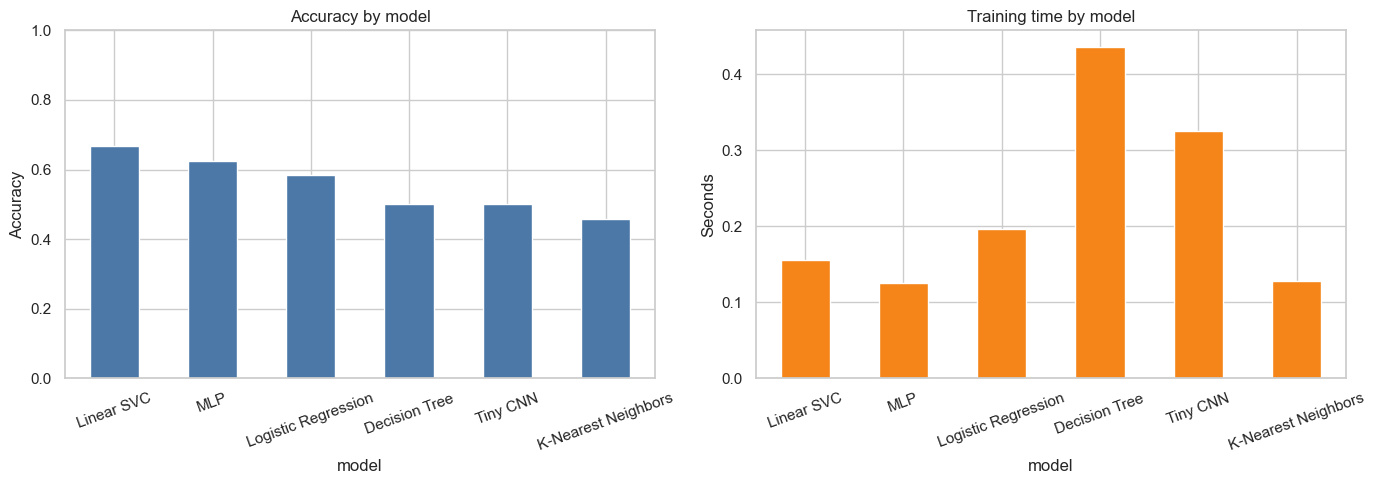

**Reflection prompts:** Which model was most accurate? Which was fastest? Did the most complex model always win? What tradeoffs mattered most for this dataset?

In [32]:
runtime_table = timing_frame(step_timings)
display(runtime_table)

comparison_table = pd.DataFrame(model_summaries)
comparison_table = comparison_table.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_table.plot(kind="bar", x="model", y="accuracy", color="#4c78a8", legend=False, ax=axes[0], title="Accuracy by model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

comparison_table.plot(kind="bar", x="model", y="train_seconds", color="#f58518", legend=False, ax=axes[1], title="Training time by model")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(Markdown(
    "**Reflection prompts:** Which model was most accurate? Which was fastest? "
    "Did the most complex model always win? What tradeoffs mattered most for this dataset?"
))


## 17. What students should notice

The dataset is small .

Reflect on these questions after running the notebook:
- Which model performed best on the clean test set?
- Which model trained fastest?
- Did the more complex model always win?
- How did the models behave on damaged images compared with the clean test split?
- Would you trust high confidence on the defect challenge set if there is no true label to compare against?
- Could augmentation improve fairness across classes?

Next step:
- use the augmentation notebook to generate a larger training set without editing the original image folders.
